# CS 435 (471) – Assignment 2

## **Title:** Discovering Customer Segments using K-Means Clustering  
**Course:** CS 435 / 471 – Machine Learning  
**Task:** Unsupervised Learning – Clustering

**Presented by:**
- Reema Alfehaid 431201292  
- Kadi Alaowimer 411214150
- Joud fahad alharbi 431201479  
- Aleen Alqwaifel 431201500  
- Bushra Ali alhusyani 421201987  

**Dataset:**   
Customer Personality Analysis (Kaggle)  
https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis


In this assignment, we apply **unsupervised learning (clustering)** to a real-world marketing dataset in order to discover **natural customer segments** and interpret them in a meaningful way.


## 1) Import Required Libraries

We import libraries for:

- **Data handling:** pandas, numpy  
- **Visualization:** matplotlib, seaborn  
- **Preprocessing & modeling:** scikit-learn (StandardScaler, KMeans, PCA)

We also set a random seed for reproducibility.


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# For nice plots
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = True

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2) Load Dataset

We use the **Customer Personality Analysis** dataset from Kaggle.

The dataset contains customer demographic and spending information collected from a retail marketing campaign. It includes variables such as age, income, family composition, and spending behavior across multiple product categories. These features help reveal customer purchasing patterns and lifestyle characteristics. The dataset is commonly used to understand customer segmentation and support targeted marketing strategies.

Steps:
1. Download the dataset CSV from Kaggle
2. Upload it into this Colab environment.


In [5]:
from google.colab import files
uploaded = files.upload()

import io
import pandas as pd

file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Loaded:", file_name)
df.head()

Saving marketing_campaign_clean_numeric.csv to marketing_campaign_clean_numeric.csv
Loaded: marketing_campaign_clean_numeric.csv


,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,1957,58138.0,0,0,58,635,88,546,172,88,...,7,0,0,0,0,0,0,3,11,1
1,1954,46344.0,1,1,38,11,1,6,2,1,...,5,0,0,0,0,0,0,3,11,0
2,1965,71613.0,0,0,26,426,49,127,111,21,...,4,0,0,0,0,0,0,3,11,0
3,1984,26646.0,1,0,26,11,4,20,10,3,...,6,0,0,0,0,0,0,3,11,0
4,1981,58293.0,1,0,94,173,43,118,46,27,...,5,0,0,0,0,0,0,3,11,0


## 3) Quick Dataset Overview

We inspect:

- Basic info (dtypes, non-null counts)
- Descriptive statistics
- Sample rows

This helps us understand which features are useful for clustering.


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2216 entries, 0 to 2215
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2216 non-null   int64  
 1   Income               2216 non-null   float64
 2   Kidhome              2216 non-null   int64  
 3   Teenhome             2216 non-null   int64  
 4   Recency              2216 non-null   int64  
 5   MntWines             2216 non-null   int64  
 6   MntFruits            2216 non-null   int64  
 7   MntMeatProducts      2216 non-null   int64  
 8   MntFishProducts      2216 non-null   int64  
 9   MntSweetProducts     2216 non-null   int64  
 10  MntGoldProds         2216 non-null   int64  
 11  NumDealsPurchases    2216 non-null   int64  
 12  NumWebPurchases      2216 non-null   int64  
 13  NumCatalogPurchases  2216 non-null   int64  
 14  NumStorePurchases    2216 non-null   int64  
 15  NumWebVisitsMonth    2216 non-null   i

In [7]:
df.describe(include="all").transpose().head(20)

,count,mean,std,min,25%,50%,75%,max
Year_Birth,2216.0,1968.820397,11.985554,1893.0,1959.0,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.0,51381.5,68522.00,666666.0
Kidhome,2216.0,0.441787,0.536896,0.0,0.0,0.0,1.00,2.0
Teenhome,2216.0,0.505415,0.544181,0.0,0.0,0.0,1.00,2.0
Recency,2216.0,49.012635,28.948352,0.0,24.0,49.0,74.00,99.0
MntWines,2216.0,305.091606,337.327920,0.0,24.0,174.5,505.00,1493.0
MntFruits,2216.0,26.356047,39.793917,0.0,2.0,8.0,33.00,199.0
MntMeatProducts,2216.0,166.995939,224.283273,0.0,16.0,68.0,232.25,1725.0
MntFishProducts,2216.0,37.637635,54.752082,0.0,3.0,12.0,50.00,259.0
MntSweetProducts,2216.0,27.028881,41.072046,0.0,1.0,8.0,33.00,262.0


## 4) Data Cleaning and Feature Selection

The dataset contains:

- **Customer ID, demographic variables** (Year_Birth, Education, Marital_Status, etc.)
- **Household information** (Kidhome, Teenhome)
- **Marketing/behavior variables** (Income, Recency, MntWines, NumDealsPurchases, etc.)

For clustering, we:

1. **Drop ID-like or non-informative columns** (e.g. `ID`, `Dt_Customer`).
2. Focus on **numeric behavioral and demographic variables**.
3. Drop rows with missing values in those selected features.


In [8]:
# Drop ID/date columns that are not useful for clustering
df_clean = df.copy()

drop_cols = ["ID", "Dt_Customer"]
for c in drop_cols:
    if c in df_clean.columns:
        df_clean = df_clean.drop(columns=[c])

# Select numeric columns only
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()
print("Numeric columns:", numeric_cols)

# Keep only numeric columns for clustering
df_numeric = df_clean[numeric_cols].copy()

# Drop rows with missing values in numeric features
before = df_numeric.shape[0]
df_numeric = df_numeric.dropna()
after = df_numeric.shape[0]

print(f"Dropped {before - after} rows due to missing values.")
print("Final numeric shape:", df_numeric.shape)

df_numeric.head()

Numeric columns: ['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']
Dropped 0 rows due to missing values.
Final numeric shape: (2216, 25)


,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,1957,58138.0,0,0,58,635,88,546,172,88,...,7,0,0,0,0,0,0,3,11,1
1,1954,46344.0,1,1,38,11,1,6,2,1,...,5,0,0,0,0,0,0,3,11,0
2,1965,71613.0,0,0,26,426,49,127,111,21,...,4,0,0,0,0,0,0,3,11,0
3,1984,26646.0,1,0,26,11,4,20,10,3,...,6,0,0,0,0,0,0,3,11,0
4,1981,58293.0,1,0,94,173,43,118,46,27,...,5,0,0,0,0,0,0,3,11,0


## 5) Basic Exploration of Numeric Features

We briefly inspect:

- Distributions  
- Correlations  

This step is not mandatory for scoring, but helps to understand the data structure.


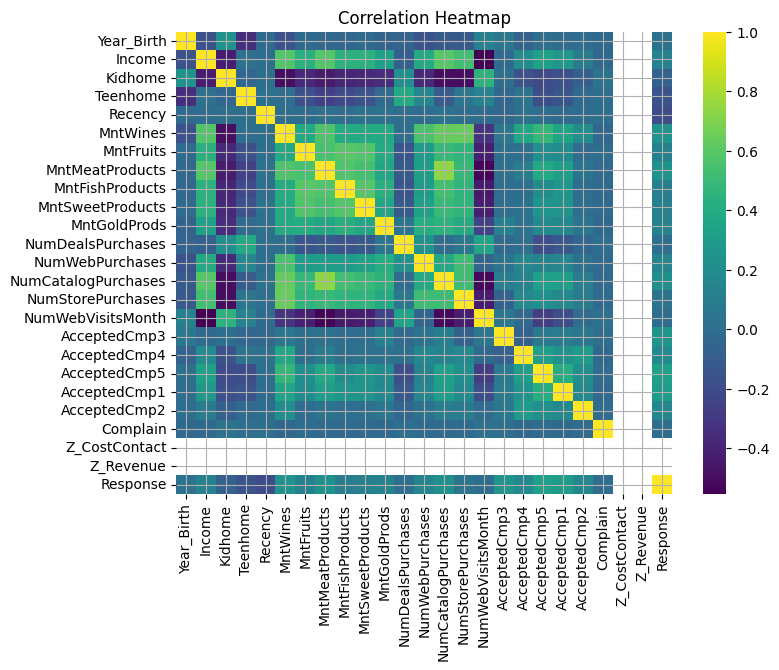

In [9]:
# Correlation heatmap (optional – can be commented out if slow)
corr = df_numeric.corr()
plt.figure()
sns.heatmap(corr, cmap="viridis")
plt.title("Correlation Heatmap")
plt.show()

## 6) Feature Scaling (Standardization)

K-Means is **sensitive to feature scales**.

We apply **StandardScaler**:

- Each feature will have mean ≈ 0 and standard deviation ≈ 1.
- Prevents features with large values (e.g. Income) from dominating the distance.


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (2216, 25)


## 7) Choosing Number of Clusters (k) – Elbow Method

We use the **Elbow Method**:

1. Fit K-Means for a range of `k` values (e.g. 2 to 10).
2. Plot `Inertia` (within-cluster sum of squared distances).
3. Look for an "elbow" where adding more clusters gives diminishing returns.

This helps us pick a reasonable `k`.


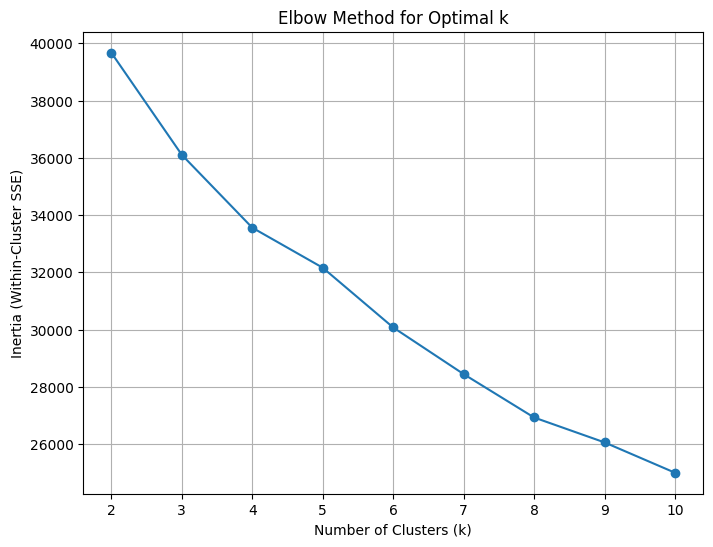

In [11]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure()
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster SSE)")
plt.title("Elbow Method for Optimal k")
plt.xticks(k_values)
plt.show()

## 8) Fit Final K-Means Model

Based on the Elbow Method, we choose a **reasonable k** (e.g. `k = 4`).

We then:

- Fit **KMeans** on the scaled features.  
- Assign each customer to a **cluster label**.  
- Attach cluster labels back to the original dataframe.


In [12]:
# Choose k (you can change this based on the elbow plot)
K = 4

kmeans_final = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to numeric dataframe (and original clean df)
df_numeric_clusters = df_numeric.copy()
df_numeric_clusters["Cluster"] = clusters

df_clusters_full = df_clean.loc[df_numeric.index].copy()
df_clusters_full["Cluster"] = clusters

df_clusters_full.head()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Cluster
0,1957,58138.0,0,0,58,635,88,546,172,88,...,0,0,0,0,0,0,3,11,1,3
1,1954,46344.0,1,1,38,11,1,6,2,1,...,0,0,0,0,0,0,3,11,0,0
2,1965,71613.0,0,0,26,426,49,127,111,21,...,0,0,0,0,0,0,3,11,0,3
3,1984,26646.0,1,0,26,11,4,20,10,3,...,0,0,0,0,0,0,3,11,0,0
4,1981,58293.0,1,0,94,173,43,118,46,27,...,0,0,0,0,0,0,3,11,0,0


## 9) Visualizing Clusters using PCA (2D Projection)

The data has many features (high dimensional).

To visualize clusters:

1. Apply **Principal Component Analysis (PCA)** to reduce to **2 components**.
2. Plot the customers in the PC1–PC2 space, colored by cluster.

This allows us to **see how clusters are separated**.


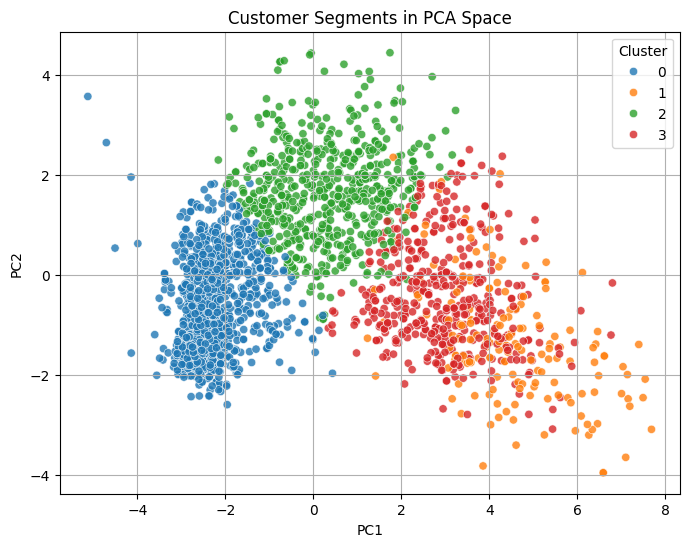

Explained variance by PC1 and PC2: 0.28, 0.09


In [13]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pc_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=df_numeric.index)
pc_df["Cluster"] = clusters

plt.figure()
sns.scatterplot(data=pc_df, x="PC1", y="PC2", hue="Cluster", palette="tab10", alpha=0.8)
plt.title("Customer Segments in PCA Space")
plt.legend(title="Cluster")
plt.show()

explained_var = pca.explained_variance_ratio_
print(f"Explained variance by PC1 and PC2: {explained_var[0]:.2f}, {explained_var[1]:.2f}")

## 10) Cluster Profiling and Interpretation

To interpret each cluster, we compute:

- The **mean value** of each feature per cluster.
- Then describe each cluster in words.

Examples of insights:

- High-income, high-spending customers.
- Low-income, low-spending but responsive to deals.
- Families with kids vs. without kids, etc.


In [14]:
cluster_profile = df_numeric_clusters.groupby("Cluster").mean().round(2)
cluster_profile

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1971.88,34541.23,0.81,0.43,49.30,39.63,4.95,22.71,6.94,4.97,...,6.49,0.08,0.01,0.00,0.00,0.00,0.01,3.0,11.0,0.10
1,1969.40,81926.74,0.05,0.13,49.57,876.81,55.53,469.05,76.64,65.33,...,3.01,0.14,0.39,0.95,0.44,0.12,0.01,3.0,11.0,0.58
2,1964.24,57273.88,0.23,0.94,48.18,449.31,19.84,127.50,27.42,20.38,...,5.78,0.06,0.13,0.00,0.03,0.01,0.01,3.0,11.0,0.10
3,1967.83,74232.87,0.05,0.23,49.27,494.83,72.28,430.69,105.74,71.13,...,2.93,0.06,0.02,0.00,0.11,0.00,0.01,3.0,11.0,0.17


In [15]:
# Display size of each cluster
cluster_sizes = df_numeric_clusters["Cluster"].value_counts().sort_index()
print("Cluster sizes:")
print(cluster_sizes)

Cluster sizes:
Cluster
0    1006
1     169
2     595
3     446
Name: count, dtype: int64


## 11) Save Final Dataset with Cluster Labels

We save the cleaned dataset with an additional **Cluster** column so it can be attached to the report.


In [17]:
output_name = "customer_clustering_with_labels.csv"
df_clusters_full.to_csv(output_name, index=False)
print(f"Saved clustered dataset to: {output_name}")

Saved clustered dataset to: customer_clustering_with_labels.csv


## 12) Conclusion

Through this clustering analysis, we successfully identified meaningful customer groups based on shared spending and demographic characteristics. Using K-Means and PCA visualizations, clear patterns emerged showing differences in purchasing habits, income levels, and family profiles across clusters. This project demonstrates how unsupervised learning can uncover hidden structures in real-world data and help businesses make informed, data-driven decisions.